In [22]:
%matplotlib inline

import sys
import yaml
import copy

import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../../')
sys.path.append('../../../../')

%load_ext autoreload
%autoreload 2
    
from computer_vision.yolov11_pose.data.dataset import YOLODataset
from computer_vision.yolov11_pose.utils import DEFAULT_CFG_DICT
from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.misc import alpha_bending, instance2mask

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
from matplotlib import patches
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab10', 10)
plt.rcParams.update({'font.size'   : 12})

In [24]:
args=parser.parse_args('--deterministic'.split())

task='segment'
if task=='pose':
    data_dirpath='D:/data/ultralytics/coco8-pose'
    data_config='../../coco8-pose.yaml'
elif task=='detect':
    data_dirpath='D:/data/ultralytics/coco/images/train2017'
    data_config='../../coco.yaml'
elif task=='segment':
    data_dirpath='D:/data/ultralytics/coco8-seg'
    data_config='../../coco8-seg.yaml'
    
dataset=YOLODataset(args=args, data=data_config, task=task, img_path=data_dirpath, imgsz=640, cache=False,augment=True, 
                    hyp=DEFAULT_CFG_DICT, prefix='',rect=False,batch_size=16,stride=32,pad=0.5, single_cls=False,classes=None,
                fraction=1.,channels=3)
for i in range(4): print(dataset.labels[i]['cls'].shape)

In data.dataset.YOLODataset.get_labels cache_path D:\data\ultralytics\coco8-seg\labels\train.cache
Scanning D:\data\ultralytics\coco8-seg\labels\train.cache... 8 images, 0 backgrounds, 0 corrupts
(8, 1)
(2, 1)
(2, 1)
(1, 1)


In [25]:
from __future__ import annotations

import math
import random
from copy import deepcopy
from typing import Any

import cv2
import numpy as np
import torch
from PIL import Image
from torch.nn import functional as F

from computer_vision.yolov11_pose.data.augment import BaseMixTransform, Mosaic, LetterBox, RandomPerspective, CopyPaste
from computer_vision.yolov11_pose.utils.instance import Instances
from computer_vision.yolov11_pose.utils.metrics import bbox_ioa

In [26]:
# mode='mixup'

# pre_transform=LetterBox(new_shape=(640,640), auto=False, center=True)
# aug_op=CopyPaste(dataset=dataset, pre_transform=pre_transform if mode=='mixup' else None, p=1., mode=mode)

# indx=1
# labels=dataset.get_image_and_label(indx) # main label
# original_labels=copy.deepcopy(labels)
# pretransformed_labels=None
# if mode=='mixup':
#     labels=pre_transform(labels)
#     pretransformed_labels=copy.deepcopy(labels)

#     # From __call__
#     # Get index of aother image
#     indexes=aug_op.get_indexes()
#     if isinstance(indexes, int): indexes=[indexes]
    
#     # Get image information will be used for copy-paste
#     mix_labels=[aug_op.dataset.get_image_and_label(i) for i in indexes]
    
#     if aug_op.pre_transform is not None:
#         for i, data in enumerate(mix_labels): mix_labels[i]=aug_op.pre_transform(data)
#     labels2=mix_labels[0]
# else: labels2={}

# final_labels=aug_op._transform(labels1=labels, labels2=labels2)

In [27]:
indx=1
labels=dataset.get_image_and_label(indx) # main label
original_labels=copy.deepcopy(labels)

mode='mixup' # 'flip' 'mixup' 

pre_transform=LetterBox(new_shape=(640,640), auto=False, center=True)
aug_op=CopyPaste(dataset=dataset, pre_transform=pre_transform if mode=='mixup' else None, p=1., mode=mode)

pretransformed_labels=None
if mode=='mixup':
    labels=pre_transform(labels)
    pretransformed_labels=copy.deepcopy(labels)

final_labels=aug_op(labels)

0 --------------------------------------------------
img  (426, 640, 3) height 426, width 640
1 --------------------------------------------------
img  (640, 640, 3) height 640, width 640
2 --------------------------------------------------
img  (640, 640, 3) height 640, width 640


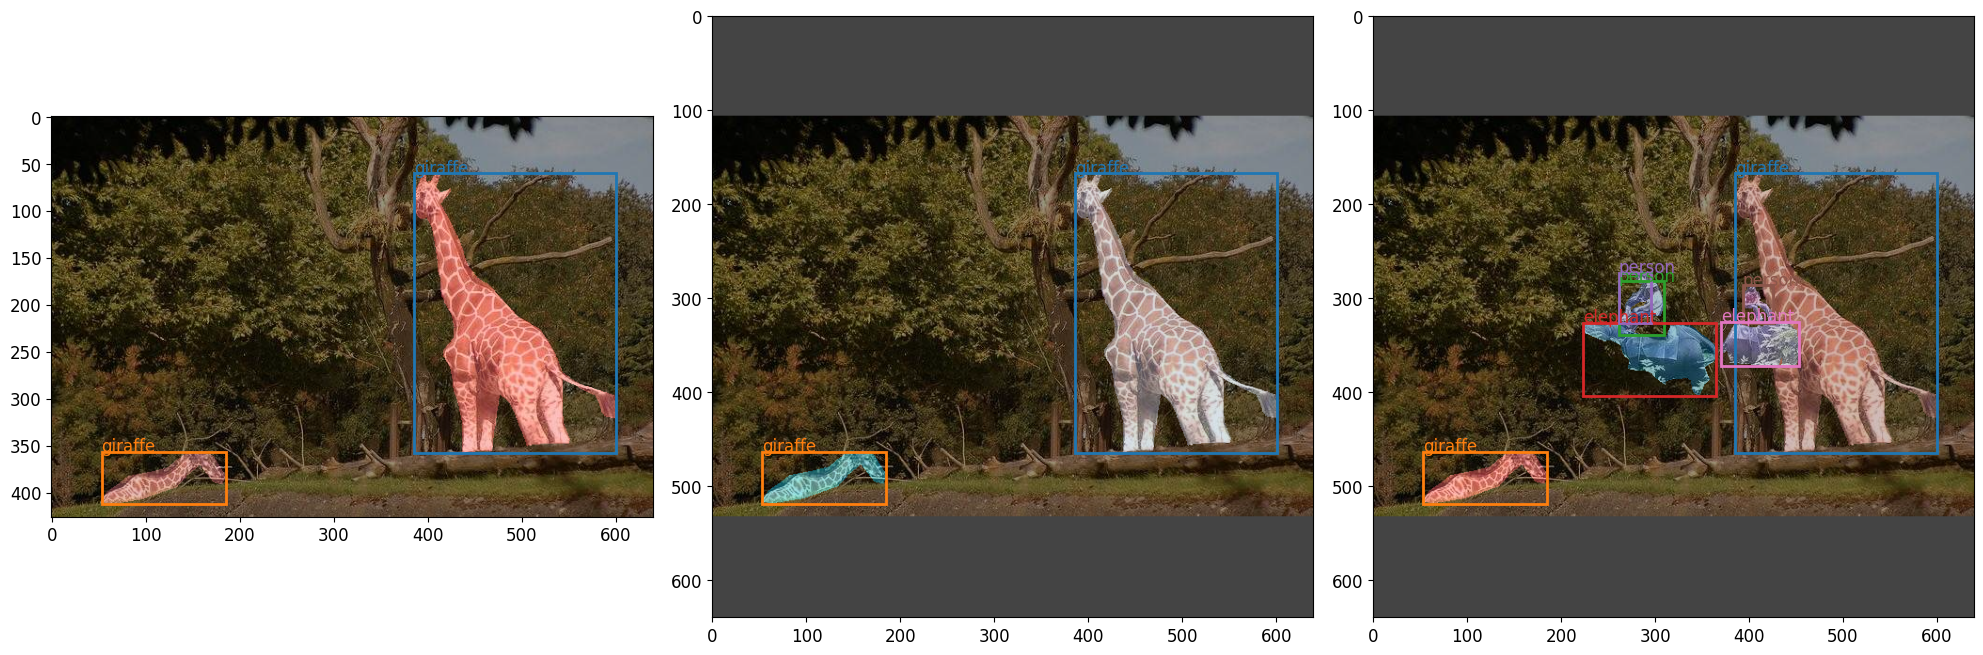

In [28]:
_, ax=plt.subplots(1,3,figsize=(20,8))
for i, labels in enumerate([original_labels,pretransformed_labels, final_labels]):
    print(i,'-'*50)
    if labels is None: continue
    classes=[dataset.data['names'][int(c)] for c in labels['cls'].flatten()]
    img=labels['img']
    height, width=img.shape[:2]
    print('img ', img.shape, f'height {height}, width {width}')
    instances=copy.deepcopy(labels['instances'])
    if instances._bboxes.format=='xywh': instances.convert_bbox('xyxy')
    if instances.normalized: instances.denormalize(width, height)
    boxes=instances.bboxes
    if hasattr(labels['instances'], 'segments') and len(getattr(labels['instances'], 'segments')):
        mask=instance2mask(image=img, instance=labels['instances'])
        ax[i].imshow(alpha_bending(mask, img[...,::-1], 0.4))
    else: ax[i].imshow(img[...,::-1])
    for j, (box,cls) in enumerate(zip(boxes, classes)):
        # Create a Rectangle patch
        rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
        # Add the patch to the Axes
        ax[i].add_patch(rect)
        ax[i].text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)
plt.tight_layout()
